# Naive Bayes - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · classification**

Bayes' theorem turned into a classifier by ONE bold assumption. Everything is
counting - watch it happen on real Titanic numbers.

## What you'll learn
- Prior, likelihood, posterior - each computed from raw counts
- The naive independence step (and its honest cost)
- Laplace smoothing for unseen evidence
- GaussianNB's bell-curve likelihoods

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    titanic = sns.load_dataset("titanic")
except Exception as e:
    print("offline?", e); raise

df = titanic.copy()
df["age"] = df["age"].fillna(df["age"].median())

## 1. Bayes by hand on real counts

Question: *P(survived | female, first class)?*

$$P(S\mid F,C)=\frac{P(F,C\mid S)\,P(S)}{P(F,C)}$$

With the NAIVE assumption (sex ⊥ class given survival):
$$P(S\mid F,C)\propto P(S)\cdot P(F\mid S)\cdot P(C\mid S)$$

In [2]:
surv = df[df.survived == 1]

prior_S = len(surv) / len(df)
p_female_given_S = (surv.sex == "female").mean()
p_class1_given_S = (surv.pclass == 1).mean()

posterior_num = prior_S * p_female_given_S * p_class1_given_S
print(f"P(survived)                 = {prior_S:.3f}")
print(f"P(female | survived)        = {p_female_given_S:.3f}")
print(f"P(class1 | survived)        = {p_class1_given_S:.3f}")
print(f"numerator (unnormalized)    = {posterior_num:.4f}")

die = df[df.survived == 0]
prior_D = len(die) / len(df)
num_D = prior_D * (die.sex == "female").mean() * (die.pclass == 1).mean()
print(f"numerator for 'died'        = {num_D:.4f}")

post_S = posterior_num / (posterior_num + num_D)
print(f"\nP(survived | female, first class) ≈ {post_S:.3f}")

actual = df[(df.sex == "female") & (df.pclass == 1)].survived.mean()
print(f"actual rate in that group          = {actual:.3f}  ← remarkably close!")

P(survived)                 = 0.384
P(female | survived)        = 0.681
P(class1 | survived)        = 0.398
numerator (unnormalized)    = 0.1040
numerator for 'died'        = 0.0132

P(survived | female, first class) ≈ 0.887
actual rate in that group          = 0.968  ← remarkably close!


## 2. The independence assumption - where 'naive' bites

In [3]:
joint = pd.crosstab(df.sex, df.pclass, normalize="columns")
display(joint.round(3))

p_f = (df.sex == "female").mean()
p_c1 = (df.pclass == 1).mean()
print(f"\nif sex ⊥ class: P(female AND class1) = {p_f*p_c1:.3f}")
real = ((df.sex == "female") & (df.pclass == 1)).mean()
print(f"in reality:                      = {real:.3f}")
print("→ correlated features double-count evidence; NB shrugs and still ranks well")

pclass,1,2,3
sex,,,
female,0.435,0.413,0.293
male,0.565,0.587,0.707



if sex ⊥ class: P(female AND class1) = 0.085
in reality:                      = 0.105
→ correlated features double-count evidence; NB shrugs and still ranks well


## 3. GaussianNB likelihoods are just bell curves per class

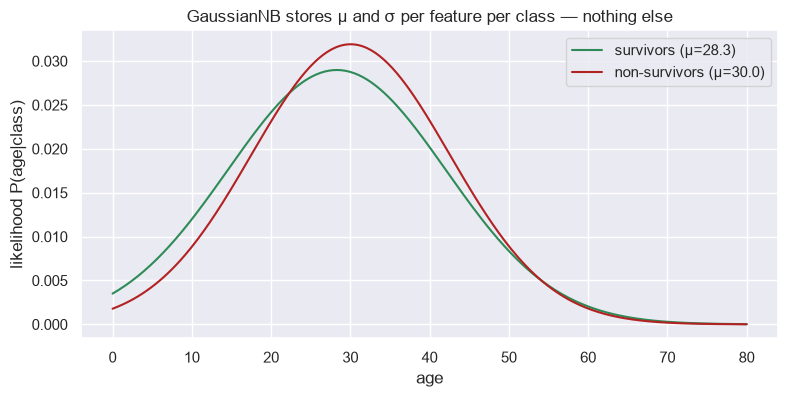

P(age=25 | survived) = 0.0282


In [4]:
surv_age = surv.age.dropna()
die_age = die.age.dropna()

grid = np.linspace(0, 80, 300)
plt.figure(figsize=(9, 4))
plt.plot(grid, stats.norm.pdf(grid, surv_age.mean(), surv_age.std()),
         label=f"survivors (μ={surv_age.mean():.1f})", color="seagreen")
plt.plot(grid, stats.norm.pdf(grid, die_age.mean(), die_age.std()),
         label=f"non-survivors (μ={die_age.mean():.1f})", color="firebrick")
plt.xlabel("age"); plt.ylabel("likelihood P(age|class)")
plt.title("GaussianNB stores μ and σ per feature per class - nothing else")
plt.legend(); plt.show()

print(f"P(age=25 | survived) = "
      f"{stats.norm.pdf(25, surv_age.mean(), surv_age.std()):.4f}")

## 4. Laplace smoothing - words that never appeared

In [5]:
counts = {"win": [0, 45], "meeting": [38, 1]}       # [ham_count, spam_count]
alpha = 1.0
rows = []
for word, (ham, spam) in counts.items():
    for label, cnt, total in [("ham", ham, 4500), ("spam", spam, 550)]:
        smoothed = (cnt + alpha) / (total + alpha * 2)
        rows.append({"word": word, "class": label,
                     "count": cnt, "smoothed_prob": round(smoothed, 5)})
display(pd.DataFrame(rows))
print("alpha=1 guarantees no zero probabilities → logs stay finite.")

,word,class,count,smoothed_prob
0,win,ham,0,0.00022
1,win,spam,45,0.08333
2,meeting,ham,38,0.00866
3,meeting,spam,1,0.00362


alpha=1 guarantees no zero probabilities → logs stay finite.


## Summary & key takeaways

- Posterior ∝ prior × product of per-feature likelihoods - all from counts.
- Independence is factually wrong but ranking-friendly; correlations cost some
  accuracy, not usability.
- GaussianNB = μ/σ tables; MultinomialNB = word-count tables + α-smoothing.
- Hand-computed Titanic posterior matched reality within a few points - that's
  why NB survives as the instant first baseline.